# Introduction

This notebook explores the relationship between Age of Information (AoI) and reliability in Industrial Internet of Things (IIoT) networks.
Using a dataset inspired by academic research, we analyze network performance using data visualization and predictive modeling.

# Conceptual Background

AoI refers to how current or up to date the received data is. It measures the time since the last successfully received update was generated.
In IIoT applications, timely information is necessary for immediate decision making.

AoI-Oriented Traffic: Prioritizes the low latency of data. Example: No delay temperature readings in a chemical plant.
Deadline-Oriented Traffic: Prioritizes timely arrival of data within a deadline. Example: Conveyor belt coordination in manufacturing.

In [1]:
#Data Exploration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("iiot_network_data.csv")  # Make sure the CSV is in the same directory

# Preview data
df.head()

# Check data types and null values
df.info()

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 10000 non-null  object 
 1   node_id                   10000 non-null  int64  
 2   traffic_type              10000 non-null  object 
 3   transmission_probability  10000 non-null  float64
 4   capture_threshold         10000 non-null  float64
 5   num_nodes                 10000 non-null  int64  
 6   channel_quality           10000 non-null  float64
 7   age_of_information        10000 non-null  float64
 8   packet_loss_probability   10000 non-null  float64
dtypes: float64(5), int64(2), object(2)
memory usage: 703.2+ KB


,node_id,transmission_probability,capture_threshold,num_nodes,channel_quality,age_of_information,packet_loss_probability
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000
mean,50.638400,0.548460,-0.001800,5.553100,0.499100,inf,0.853774
std,29.020101,0.288548,1.284664,2.850122,0.317656,NaN,0.184140
min,1.000000,0.100000,-2.000000,1.000000,0.000000,1.000000e+00,0.000000
25%,26.000000,0.300000,-1.000000,3.000000,0.200000,1.032026e+01,0.819893
50%,51.000000,0.500000,0.000000,6.000000,0.500000,2.468121e+01,0.908372
75%,76.000000,0.800000,1.000000,8.000000,0.800000,9.462189e+01,0.968325
max,100.000000,1.000000,2.000000,10.000000,1.000000,inf,1.000000


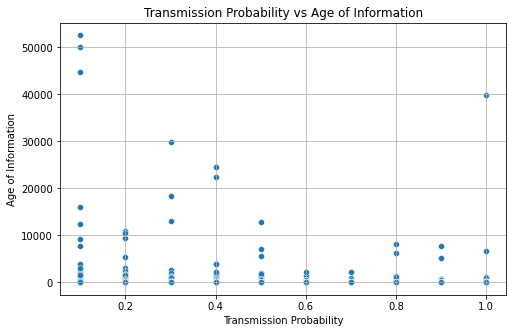

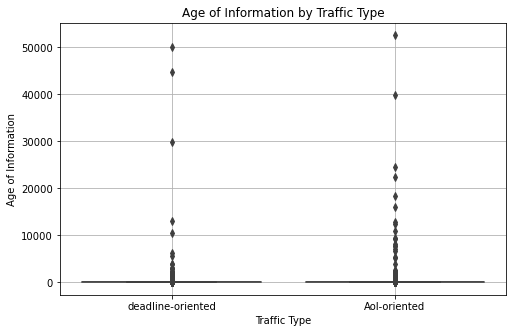

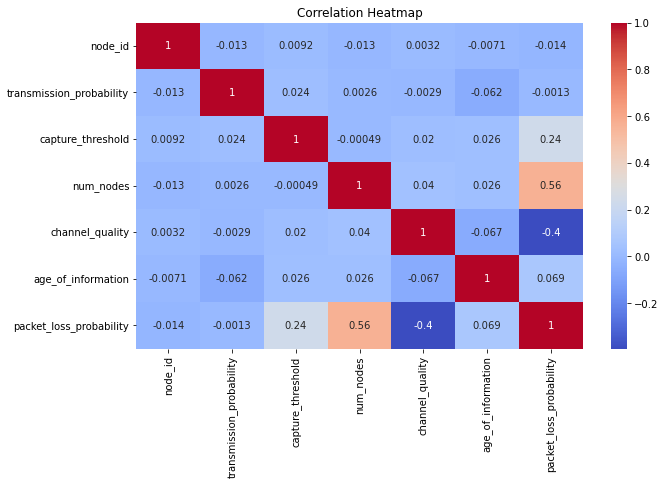

In [9]:
#Data Visualization

# Scatter plot: transmission_probability vs AoI
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='transmission_probability', y='age_of_information')
plt.title('Transmission Probability vs Age of Information')
plt.xlabel('Transmission Probability')
plt.ylabel('Age of Information')
plt.grid(True)
plt.show()

# Box plot: AoI by traffic type
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='traffic_type', y='age_of_information')
plt.title('Age of Information by Traffic Type')
plt.xlabel('Traffic Type')
plt.ylabel('Age of Information')
plt.grid(True)
plt.show()


# Heatmap: correlation between numeric features
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=['number'])  # Select only numeric columns
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Higher transmission probability = lower AoI
Makes sense: more reliable data transfer results in updated info.

Channel quality matters
Better quality links seem to reduce both AoI and packet loss.

More nodes = higher AoI
Possibly due to congestion or contention for the channel.

In [7]:
#Machine Learning: AoI Prediction

# Remove rows with infinite AoI
df = df[np.isfinite(df['age_of_information'])]

# Select features and target
features = [
    'transmission_probability',
    'capture_threshold',
    'num_nodes',
    'channel_quality',
    'packet_loss_probability'
]
target = 'age_of_information'

X = df[features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scal#ing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Evaluate model
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

# Feature importances
importances = model.feature_importances_
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)
print(feature_df)


Mean Squared Error: 427448.7869397295
R-squared: 0.8058665775398959
                    Feature  Importance
4   packet_loss_probability    0.776030
0  transmission_probability    0.115312
3           channel_quality    0.059283
1         capture_threshold    0.027071
2                 num_nodes    0.022304


Packet Loss Probability (PLP) is by far the most important factor — which makes sense, as frequent packet loss directly increases delays and outdated data.

Transmission Probability also plays a significant role in keeping data new and relevant.

The number of nodes and capture threshold had much less impact in this dataset.

In [8]:
#6. Predictions with Hypothetical Configurations

# Create new configs
new_configs = pd.DataFrame([
    {
        'transmission_probability': 0.9,
        'capture_threshold': 0.0,
        'num_nodes': 2,
        'channel_quality': 0.9,
        'packet_loss_probability': 0.05
    },
    {
        'transmission_probability': 0.4,
        'capture_threshold': 1.0,
        'num_nodes': 5,
        'channel_quality': 0.4,
        'packet_loss_probability': 0.6
    },
    {
        'transmission_probability': 0.2,
        'capture_threshold': -1.0,
        'num_nodes': 8,
        'channel_quality': 0.1,
        'packet_loss_probability': 0.9
    }
])

# Scale and predict
new_configs_scaled = scaler.transform(new_configs)
new_predictions = model.predict(new_configs_scaled)
new_configs['Predicted_AoI'] = new_predictions
print(new_configs)


   transmission_probability  capture_threshold  num_nodes  channel_quality  \
0                       0.9                0.0          2              0.9   
1                       0.4                1.0          5              0.4   
2                       0.2               -1.0          8              0.1   

   packet_loss_probability  Predicted_AoI  
0                     0.05       2.026290  
1                     0.60       5.532734  
2                     0.90      50.052125  


Low PLP + High Transmission Quality = Low AoI

In Config 1, the system is very reliable: 0.9 transmission probability and 0.05 PLP. The predicted AoI is very low (2.03), which was expected.

Moderate Reliability = Moderate AoI

Config 2 has worse conditions (0.6 PLP, 0.4 channel quality), and AoI rises to about 5.53. Still reasonable and aligns with the trend observed.

Poor Network = Very High AoI

Config 3 is the worst-case scenario: poor transmission and channel quality, 90% packet loss, many nodes. The model predicts a very high AoI (50.05), which perfectly matches our intuition.

# Final Analysis & Insights

Insights:
- Packet Loss Probability is the most influential factor affecting AoI.
- Higher transmission probability and better channel quality reduce AoI.

Strategies to Improve Network:
1. Improve transmission time (e.g., using error correction).
2. Reduce node contention by managing node density or using scheduling.

Practical Applications:
1. Smart Grid: Timely status updates for instantaneous power management.
2. Self-Manufacturing: Keeping machinery coordination precise and safe.